Title: LEE_Detection_new_with_PP_code.ipynb

Purpose: Identifiy Low Energy Events with varying lengths from the model output data

Author: Onno Nennecke on 21.03.2025 Modified: 19.03.2026

Input data: 

- adjusted final model output
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'

Output data:



In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob
import matplotlib.pyplot as plt
from scipy import stats
from collections import Counter



### Read Model output data

In [2]:
# path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
# path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'

ts_datasets = xr.open_dataset(path)
ts_datasets.load()

# Without SMARD ESM_run
ts_datasets = ts_datasets.where(
    ts_datasets.ESM_run != 'SMARD_hist',
    drop=True
)
ts_datasets


path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'
ts_datasets_fut = xr.open_dataset(path)
ts_datasets_fut.load()


<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 192, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 1.208 -0.303 ... 6.245 7.776
    demand         (ESM_run, time) float64 6MB 1.505e+03 1.524e+03 ... 1.422e+03
    sfcWind        (ESM_run, time) float64 6MB 4.406 6.058 5.642 ... 6.601 8.858
    rsds           (ESM_run, time) float32 3MB 23.72 30.12 26.28 ... 32.49 20.75
    tas            (ESM_run, time) float32 3MB 1.553 0.233 ... 6.191 7.687
    tasmax         (ESM_run, time) float32 3MB 2.524 1.048 ... 9.226 9.364
    wind_off_prod  (ESM_run, time) float64 6MB 92.24 77.15 30.34 ... 166.3 147.1
    wind_on_prod   (ESM_run, time) float64 6MB 153.1 321.4 ... 539.8 1.166e+03
    solar_prod     (ESM_run, time) float64 6MB 38.47 53.53 46.18 ... 61.05 37.61
    total_prod     (ESM_run, time) float64 6MB 283.8 452.1 ... 767.1 1.351e+03
    Netto          (ESM_run, time) float64 6MB -1.221e+03 -1.072e+03 ... -71.73
    Residual_load  (ESM_run, time) float64 6MB 1.221e+03 1.072e+03 ... 71.73

#### Identification of low energy events

In [3]:
# RL = ts_datasets['Residual_load_adj']
RL = ts_datasets['Residual_load']
RL_fut = ts_datasets_fut['Residual_load']
# # Calculate the rolling means
# ts_datasets['RL_mov_avg_7'] = RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
# ts_datasets['RL_mov_avg_14'] = RL_mov_avg_14 = RL.rolling(time=14, center=False).mean()

thresh_perc = 0.95
# Select all ESM_runs with period 'week'
ts_datasets_week = ts_datasets.sel(ESM_run=ts_datasets.ESM_run[ts_datasets.period == 'week'])
RL_week = ts_datasets_week['Residual_load']
threshold_week = np.quantile(RL_week.values.flatten(), thresh_perc)
threshold_week

np.float64(1319.138650687668)

In [4]:
# Time series of "True" when threshold is exceeded, "False" otherwise
exceed_bool_1 = xr.where(RL > threshold_week, True, False)
exceed_bool_1_fut = xr.where(RL_fut > threshold_week, True, False)
# exceed_bool_7 = xr.where(RL_mov_avg_7 > threshold_week, True, False)
# exceed_bool_14 = xr.where(RL_mov_avg_14 > threshold_week, True, False)

In [5]:
def rle(inarray):
    """ run length encoding. Partial credit to R rle function. 
        Multi datatype arrays catered for including non Numpy
        returns: tuple (runlengths, startpositions, values) """
    ia = np.asarray(inarray)                # force numpy
    n = len(ia)
    if n == 0: 
        return (None, None, None)
    else:
        y = ia[1:] != ia[:-1]               # pairwise unequal (string safe)
        i = np.append(np.where(y), n - 1)   # must include last element posi
        z = np.diff(np.append(-1, i))       # run lengths
        p = np.cumsum(np.append(0, z))[:-1] # positions
        return(z, p, ia[i])
# length,position,type = rle(np.array([0,0,0,0,1,1,0,0,1,1]))
# print(length,position,type,length[type==0])


In [6]:
exceed_bool_1

<xarray.DataArray 'Residual_load' (ESM_run: 193, time: 3650)> Size: 704kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False,  True, ..., False, False,  True],
       [False, False, False, ..., False,  True,  True]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week' 'week'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

In [7]:
exceed_bool_1

hist_dict = {'ESM': [],
             'x': [],
             'freq': []}

# x_hist_list = []
# freq_hist_list = []
for esm in np.unique(ts_datasets.ESM):
    hist_dict['ESM'].append(esm)
    subset = exceed_bool_1.where(exceed_bool_1.ESM == esm, drop=True)
    # ESM_exceed_bool_1_list.append(subset)
    total_counts_hist = Counter()
    for i in range(len(subset.ESM_run.values)):
        length,position,type = rle(subset[i].values)
        counts = Counter(length[type==True])
            # Add to global counter
        total_counts_hist.update(counts)
        
    x_hist = np.array(sorted(total_counts_hist.keys()))
    freq_hist = np.array([total_counts_hist[i] for i in x_hist])
    hist_dict['x'].append(x_hist)
    hist_dict['freq'].append(freq_hist)
    # x_hist_list.append(x_hist)
    # freq_hist_list.append(freq_hist)

fut_dict = {'ESM': [],
             'x': [],
             'freq': []}

# x_fut_list = []
# freq_fut_list = []
for esm in np.unique(ts_datasets_fut.ESM):
    fut_dict['ESM'].append(esm)
    subset = exceed_bool_1_fut.where(exceed_bool_1_fut.ESM == esm, drop=True)
    # ESM_exceed_bool_1_list.append(subset)
    total_counts_fut = Counter()
    for i in range(len(subset.ESM_run.values)):
        length,position,type = rle(subset[i].values)
        counts = Counter(length[type==True])
            # Add to global counter
        total_counts_fut.update(counts)
        
    x_fut = np.array(sorted(total_counts_fut.keys()))
    freq_fut = np.array([total_counts_fut[i] for i in x_fut])

    fut_dict['x'].append(x_fut)
    fut_dict['freq'].append(freq_fut)
    # x_fut_list.append(x_fut)
    # freq_fut_list.append(freq_fut)


In [8]:
num_RL_days = exceed_bool_1.values.sum().sum()
print(num_RL_days)
num_all_days = len(exceed_bool_1.values.flatten())
print(num_all_days)

35223
704450


In [ ]:
# Create an array with len 704450 where random 35223 values are True and the rest False
random_array = np.array([True]*num_RL_days + [False]*(num_all_days-num_RL_days))
np.random.shuffle(random_array)
random_array
length,position,type = rle(random_array)
counts_random = Counter(length[type==True])
counts_random
x_rand = np.array(sorted(counts_random.keys()))
freq_rand = np.array([counts_random[i] for i in x_rand])

In [10]:
freq_hist
counters = 0
for i in counts_random.keys():
    counters += counts_random[i] * i
print(counters)

35223


In [17]:
# Create an array with len 704450 where random 35223 values are True and the rest False
random_array_win = np.array([True]*num_RL_days + [False]*(int((num_all_days/2-1))-num_RL_days))
np.random.shuffle(random_array_win)
random_array_win
length,position,type = rle(random_array_win)
counts_random_win = Counter(length[type==True])
counts_random_win
x_rand_win = np.array(sorted(counts_random_win.keys()))
freq_rand_win = np.array([counts_random_win[i] for i in x_rand_win])

In [12]:
# Store x and freq for all ESM_runs
total_counts_hist = Counter()
for i in range(len(exceed_bool_1.ESM_run.values)):
    length,position,type = rle(exceed_bool_1[i].values)
    counts = Counter(length[type==True])
        # Add to global counter
    total_counts_hist.update(counts)
    
x_hist = np.array(sorted(total_counts_hist.keys()))
freq_hist = np.array([total_counts_hist[i] for i in x_hist])

# Store x and freq for all ESM_runs
total_counts_fut = Counter()
for i in range(len(exceed_bool_1_fut.ESM_run.values)):
    length,position,type = rle(exceed_bool_1_fut[i].values)
    counts = Counter(length[type==True])
        # Add to global counter
    total_counts_fut.update(counts)
    
x_fut = np.array(sorted(total_counts_fut.keys()))
freq_fut = np.array([total_counts_fut[i] for i in x_fut])

In [13]:
print(x_hist)
print(x_fut)
print(freq_hist)
print(freq_fut)
print(sum(freq_hist))
print(sum(freq_fut))

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 19 20 21]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
[9249 3875 1828  951  510  293  201  121   80   43   36   18    9    5
    7    4    1    3    2    1]
[8615 3457 1583  814  492  290  170   95   59   44   27   16   10    7
    7    5    1    3    1    1]
17237
15697


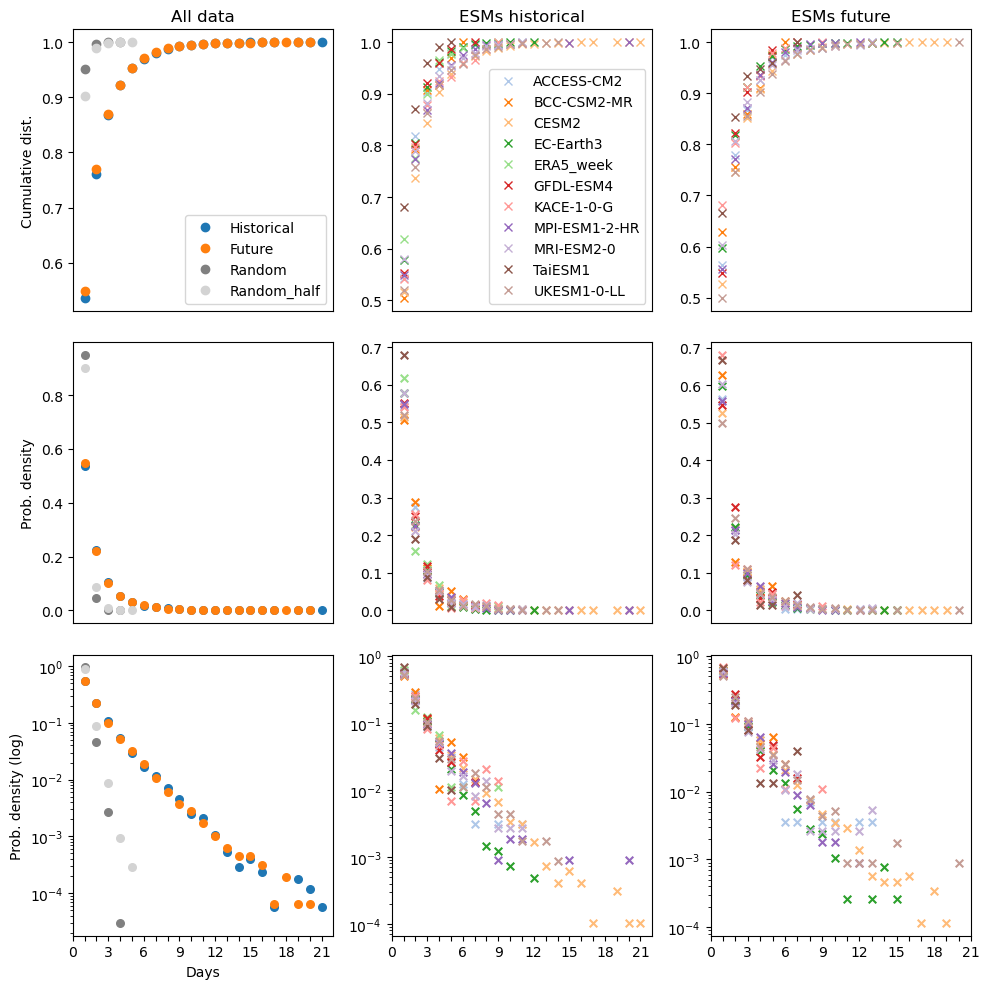

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

point_size = 30

# Set colours for ESMs
colors = plt.cm.tab20.colors[1:12]  # Get a list of 11 distinct colors
esm_colors = {esm: colors[i % len(colors)] for i, esm in enumerate(hist_dict['ESM'])}

# -----------------------------
# 1️⃣ CDF (Top Panel)
# -----------------------------
cdf_hist = np.cumsum(freq_hist) / np.sum(freq_hist)
axes[0, 0].plot(x_hist, cdf_hist, 'o', color='#1f77b4')
cdf_fut = np.cumsum(freq_fut) / np.sum(freq_fut)
axes[0, 0].plot(x_fut, cdf_fut, 'o', color='#ff7f0e')
cdf_rand = np.cumsum(freq_rand) / np.sum(freq_rand)
axes[0, 0].plot(x_rand, cdf_rand, 'o', color='gray', label='Random')
cdf_rand_win = np.cumsum(freq_rand_win) / np.sum(freq_rand_win)
axes[0, 0].plot(x_rand_win, cdf_rand_win, 'o', color='lightgray', label='Random_half')

axes[0, 0].set_title("All data")
axes[0, 1].set_title("ESMs historical")
axes[0, 2].set_title("ESMs future")
axes[0,0].legend(['Historical', 'Future', 'Random', 'Random_half'])

for esm in hist_dict['ESM']:
    x_hist_esm = hist_dict['x'][hist_dict['ESM'].index(esm)]
    freq_hist_esm = hist_dict['freq'][hist_dict['ESM'].index(esm)]
    cdf_hist_esm = np.cumsum(freq_hist_esm) / np.sum(freq_hist_esm)
    axes[0, 1].plot(x_hist_esm, cdf_hist_esm, 'x', label=esm, color=esm_colors[esm])
for esm in fut_dict['ESM']:
    x_fut_esm = fut_dict['x'][fut_dict['ESM'].index(esm)]
    freq_fut_esm = fut_dict['freq'][fut_dict['ESM'].index(esm)]
    cdf_fut_esm = np.cumsum(freq_fut_esm) / np.sum(freq_fut_esm)
    axes[0, 2].plot(x_fut_esm, cdf_fut_esm, 'x', label=esm, color=esm_colors[esm])
axes[0, 0].set_ylabel("Cumulative dist.")
# axes[0, 0].set_title("Cumulative Distribution")
axes[0, 0].set_xticks([])
axes[0, 1].set_xticks([])
axes[0, 2].set_xticks([])
axes[0, 1].legend()
# axes[0, 2].legend()


# -----------------------------
# 2️⃣ Probability Density
# -----------------------------
prob_hist = freq_hist / np.sum(freq_hist)
prob_fut = freq_fut / np.sum(freq_fut)
prob_rand = freq_rand / np.sum(freq_rand)
prob_rand_win = freq_rand_win / np.sum(freq_rand_win)
axes[1, 0].scatter(x_hist, prob_hist, color='#1f77b4', s=point_size)
axes[1, 0].scatter(x_fut, prob_fut, color='#ff7f0e', s=point_size)
axes[1, 0].scatter(x_rand, prob_rand, color='gray', s=point_size, label='Random')
axes[1, 0].scatter(x_rand_win, prob_rand_win, color='lightgray', s=point_size, label='Random_half')
for esm in hist_dict['ESM']:
    x_hist_esm = hist_dict['x'][hist_dict['ESM'].index(esm)]
    freq_hist_esm = hist_dict['freq'][hist_dict['ESM'].index(esm)]
    prob_hist_esm = freq_hist_esm / np.sum(freq_hist_esm)
    axes[1, 1].scatter(x_hist_esm, prob_hist_esm, label=esm, s=point_size, marker='x', color=esm_colors[esm])
for esm in fut_dict['ESM']:
    x_fut_esm = fut_dict['x'][fut_dict['ESM'].index(esm)]
    freq_fut_esm = fut_dict['freq'][fut_dict['ESM'].index(esm)]
    prob_fut_esm = freq_fut_esm / np.sum(freq_fut_esm)
    axes[1, 2].scatter(x_fut_esm, prob_fut_esm, label=esm, s=point_size, marker='x', color=esm_colors[esm])

axes[1, 0].set_ylabel("Prob. density")
# axes[1, 0].set_title("Probability Density")
axes[1, 0].set_xticks([])
axes[1, 1].set_xticks([])
axes[1, 2].set_xticks([])
# axes[1, 1].legend()
# axes[1, 2].legend()
# -----------------------------
# 3️⃣ Log Plot
# -----------------------------
axes[2, 0].scatter(x_hist, prob_hist, color='#1f77b4', s=point_size)
axes[2, 0].scatter(x_fut, prob_fut, color='#ff7f0e', s=point_size)
axes[2, 0].scatter(x_rand, prob_rand, color='gray', s=point_size, label='Random')
axes[2, 0].scatter(x_rand_win, prob_rand_win, color='lightgray', s=point_size, label='Random_half')
for esm in hist_dict['ESM']:
    x_hist_esm = hist_dict['x'][hist_dict['ESM'].index(esm)]
    freq_hist_esm = hist_dict['freq'][hist_dict['ESM'].index(esm)]
    prob_hist_esm = freq_hist_esm / np.sum(freq_hist_esm)
    axes[2, 1].scatter(x_hist_esm, prob_hist_esm, label=esm, s=point_size, marker='x', color=esm_colors[esm])
for esm in fut_dict['ESM']:
    x_fut_esm = fut_dict['x'][fut_dict['ESM'].index(esm)]
    freq_fut_esm = fut_dict['freq'][fut_dict['ESM'].index(esm)]
    prob_fut_esm = freq_fut_esm / np.sum(freq_fut_esm)
    axes[2, 2].scatter(x_fut_esm, prob_fut_esm, label=esm, s=point_size, marker='x', color=esm_colors[esm])
axes[2, 0].set_yscale("log")
axes[2, 1].set_yscale("log")
axes[2, 2].set_yscale("log")
# axes[2, 0].set_xscale("log")
axes[2, 0].set_xlabel("Days")
axes[2, 0].set_ylabel("Prob. density (log)")
# axes[2, 0].set_title("Log View")
axes[2, 0].set_xticks(range(0, max(x_hist)+1, 1))
axes[2, 0].set_xticklabels([str(t) if t % 3 == 0 else "" for t in range(0, max(x_hist)+1, 1)])
axes[2, 1].set_xticks(range(0, max(x_hist)+1, 1))
axes[2, 1].set_xticklabels([str(t) if t % 3 == 0 else "" for t in range(0, max(x_hist)+1, 1)])
axes[2, 2].set_xticks(range(0, max(x_hist)+1, 1))
axes[2, 2].set_xticklabels([str(t) if t % 3 == 0 else "" for t in range(0, max(x_hist)+1, 1)])
# axes[2, 1].legend()
# axes[2, 2].legend()
plt.tight_layout()
plt.show()

## Old only first column plot

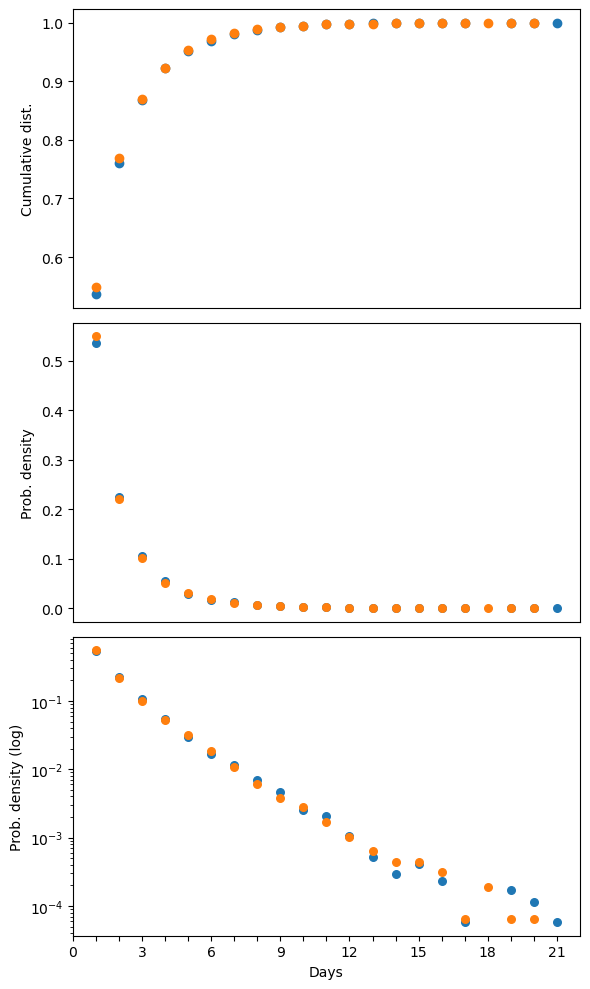

In [56]:
fig, axes = plt.subplots(3, 1, figsize=(6, 10))

point_size = 30

# -----------------------------
# 1️⃣ CDF (Top Panel)
# -----------------------------
cdf_hist = np.cumsum(freq_hist) / np.sum(freq_hist)
axes[0].plot(x_hist, cdf_hist, 'o', color='#1f77b4')
cdf_fut = np.cumsum(freq_fut) / np.sum(freq_fut)
axes[0].plot(x_fut, cdf_fut, 'o', color='#ff7f0e')
axes[0].set_ylabel("Cumulative dist.")
# axes[0].set_title("Cumulative Distribution")
axes[0].set_xticks([])

# -----------------------------
# 2️⃣ Probability Density
# -----------------------------
prob_hist = freq_hist / np.sum(freq_hist)
prob_fut = freq_fut / np.sum(freq_fut)
axes[1].scatter(x_hist, prob_hist, color='#1f77b4', s=point_size)
axes[1].scatter(x_fut, prob_fut, color='#ff7f0e', s=point_size)
axes[1].set_ylabel("Prob. density")
# axes[1].set_title("Probability Density")
axes[1].set_xticks([])
# -----------------------------
# 3️⃣ Log-Log Plot
# -----------------------------
axes[2].scatter(x_hist, prob_hist, color='#1f77b4', s=point_size)
axes[2].scatter(x_fut, prob_fut, color='#ff7f0e', s=point_size)
axes[2].set_yscale("log")
# axes[2].set_xscale("log")
axes[2].set_xlabel("Days")
axes[2].set_ylabel("Prob. density (log)")
# axes[2].set_title("Log View")
axes[2].set_xticks(range(0, max(x_hist)+1, 1))
axes[2].set_xticklabels([str(t) if t % 3 == 0 else "" for t in range(0, max(x_hist)+1, 1)])

plt.tight_layout()
plt.show()